In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
current_pwd = os.getcwd()

possible_paths = [
    '/home/export/soheuny/SRFinder/soheun/notebooks', 
    '/home/soheuny/HH4bsim/soheun/notebooks'
]
    
assert os.getcwd() in possible_paths, f"Did you change the path? It should be one of {possible_paths}"
os.chdir("..")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import torch
import tqdm
from pathlib import Path
from plots import hist_events_by_labels
from events_data import EventsData
from fvt_classifier import FvTClassifier
# import LogNorm
from matplotlib.colors import LogNorm
from training_info import TrainingInfo
from attention_classifier import AttentionClassifier
from plots import plot_rewighted_samples_by_model, plot_samples_raw
from dataset import MotherSamples
from events_data import events_from_scdinfo
import pickle

features = [
    "sym_Jet0_pt", "sym_Jet1_pt", "sym_Jet2_pt", "sym_Jet3_pt",
    "sym_Jet0_eta", "sym_Jet1_eta", "sym_Jet2_eta", "sym_Jet3_eta",
    "sym_Jet0_phi", "sym_Jet1_phi", "sym_Jet2_phi", "sym_Jet3_phi",  
    "sym_Jet0_m", "sym_Jet1_m", "sym_Jet2_m", "sym_Jet3_m",
]

# use tex
plt.rcParams["text.usetex"] = True
# plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = "Times New Roman"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.titlesize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 20
plt.rcParams["lines.markersize"] = 3

import pandas as pd

path_3b = Path("../events/MG3/dataframes/threeTag_picoAOD.h5")
path_4b = Path("../events/MG3/dataframes/fourTag_10x_picoAOD.h5")
path_signal = Path("../events/MG3/dataframes/HH4b_picoAOD.h5")
df_3b = pd.read_hdf(path_3b)
df_bg4b = pd.read_hdf(path_4b)
df_signal = pd.read_hdf(path_signal)
df_3b["signal"] = False
df_bg4b["signal"] = False
df_signal["signal"] = True
raw_df_list = [df_3b, df_bg4b, df_signal]
loaded_df = {path_3b: df_3b, path_4b: df_bg4b, path_signal: df_signal}

signal_ratio 0.0 SR_CR_size 0.05 0.95


  0%|          | 0/3 [00:00<?, ?it/s]

p_value_MCE: 0.061, p_value_AUC: 0.0, p_value_RENYI: 0.0


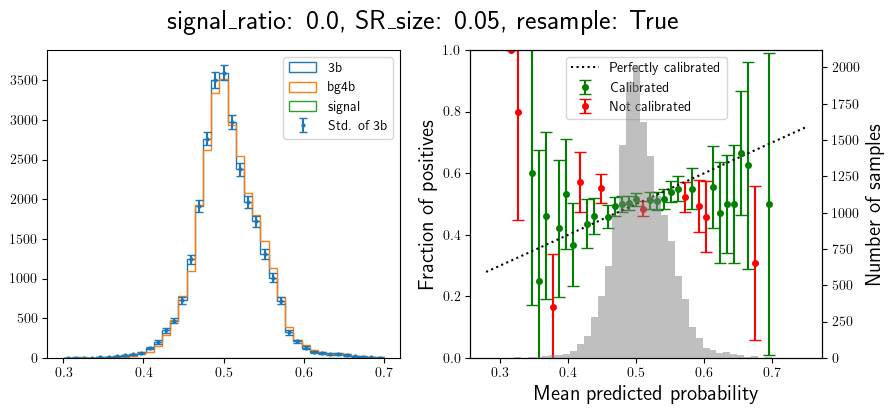

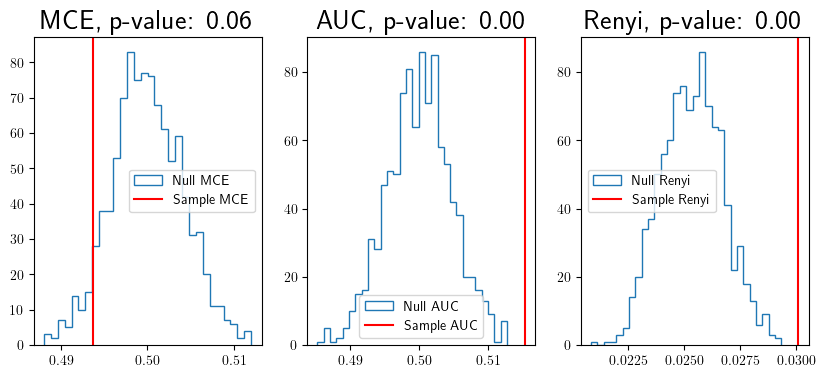

 33%|███▎      | 1/3 [00:06<00:12,  6.32s/it]

p_value_MCE: 0.0, p_value_AUC: 0.0, p_value_RENYI: 0.0


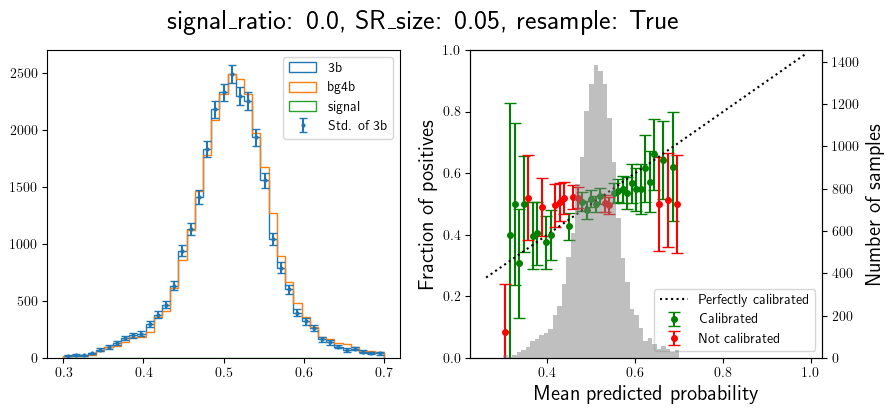

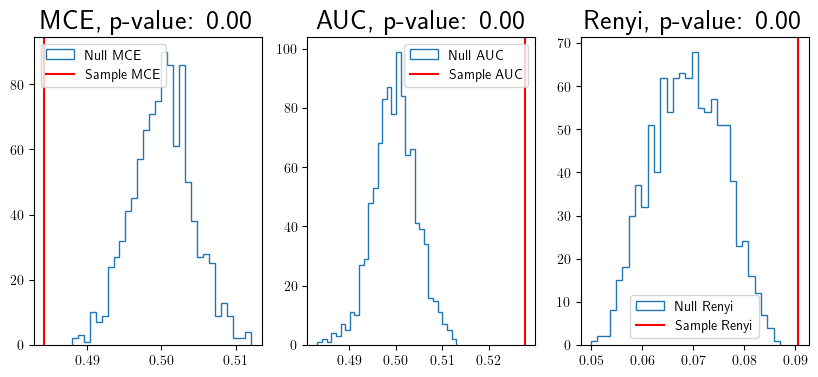

 67%|██████▋   | 2/3 [00:09<00:04,  4.58s/it]

p_value_MCE: 0.0, p_value_AUC: 0.0, p_value_RENYI: 0.0


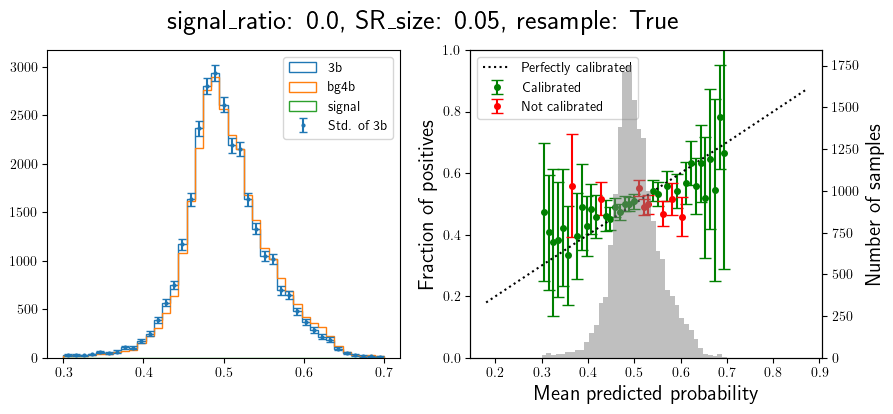

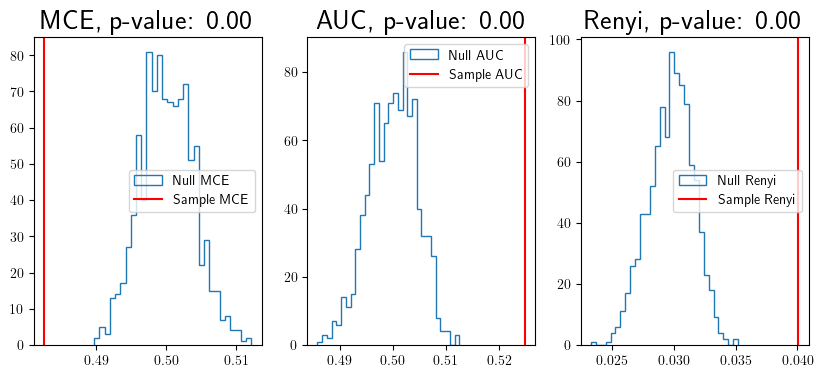

100%|██████████| 3/3 [00:12<00:00,  4.28s/it]


signal_ratio 0.0 SR_CR_size 0.1 0.9


  0%|          | 0/3 [00:00<?, ?it/s]

p_value_MCE: 0.001, p_value_AUC: 0.0, p_value_RENYI: 0.0


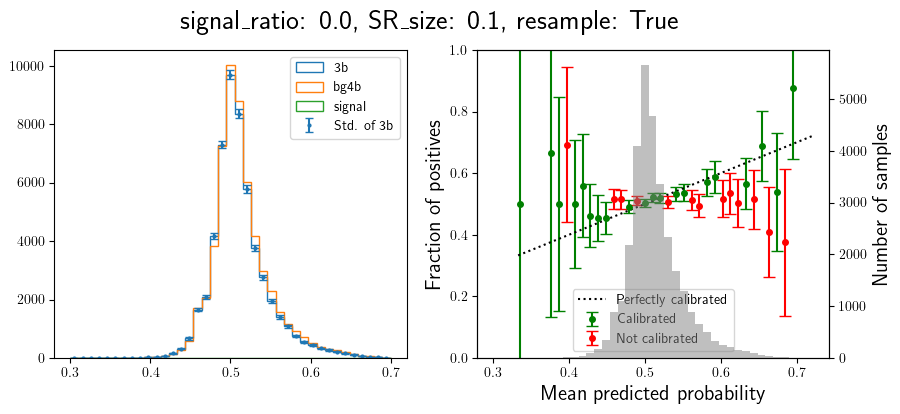

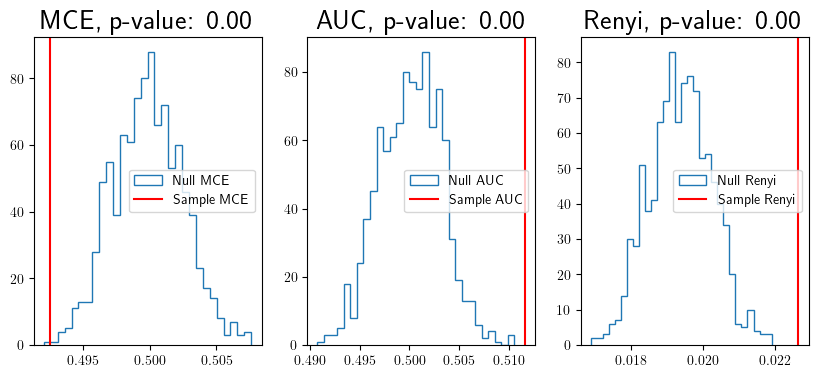

 33%|███▎      | 1/3 [00:04<00:08,  4.47s/it]

p_value_MCE: 0.0, p_value_AUC: 0.0, p_value_RENYI: 0.0


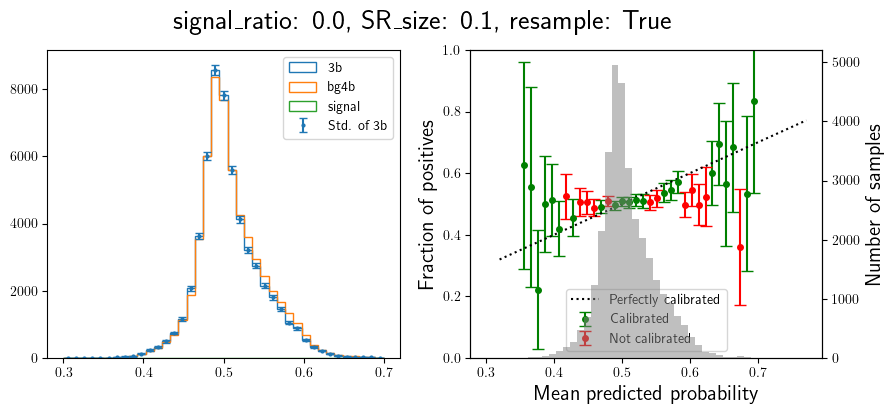

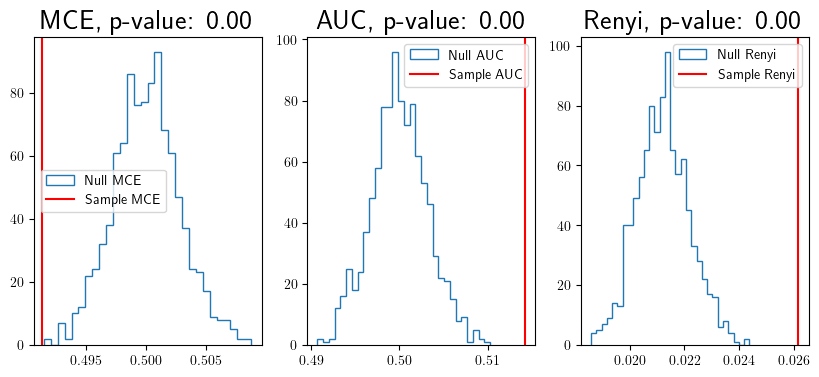

 67%|██████▋   | 2/3 [00:08<00:04,  4.21s/it]

p_value_MCE: 0.0, p_value_AUC: 0.0, p_value_RENYI: 0.0


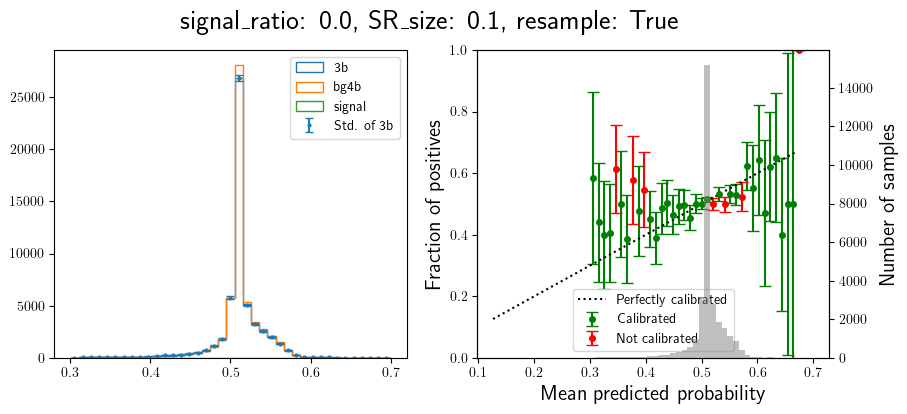

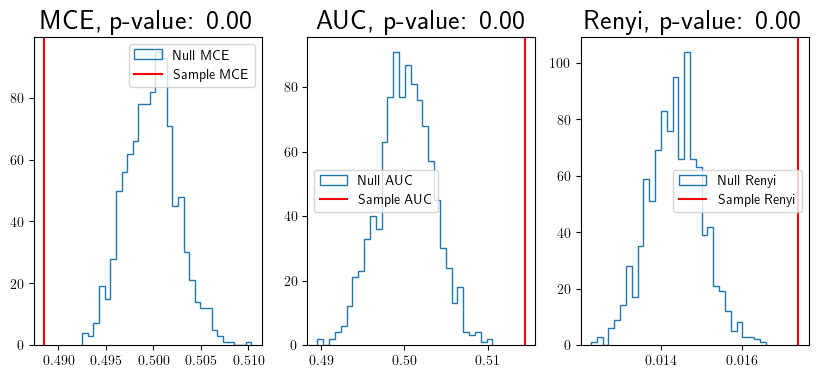

100%|██████████| 3/3 [00:12<00:00,  4.28s/it]


signal_ratio 0.0 SR_CR_size 0.15 0.85


  0%|          | 0/3 [00:00<?, ?it/s]

p_value_MCE: 0.0, p_value_AUC: 0.0, p_value_RENYI: 0.0


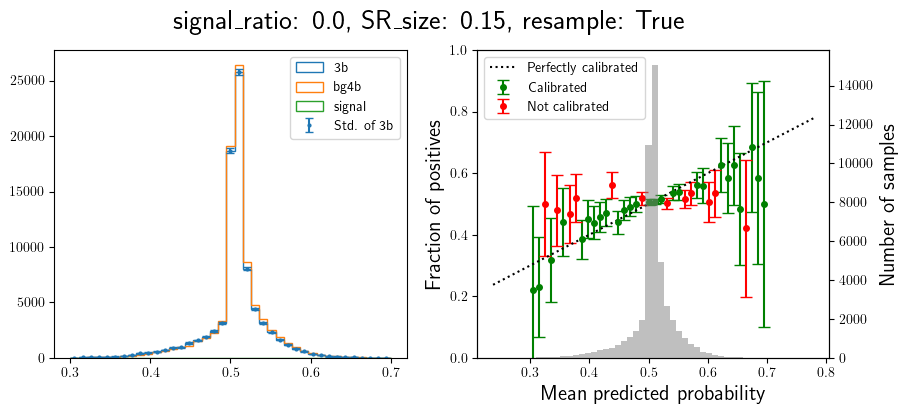

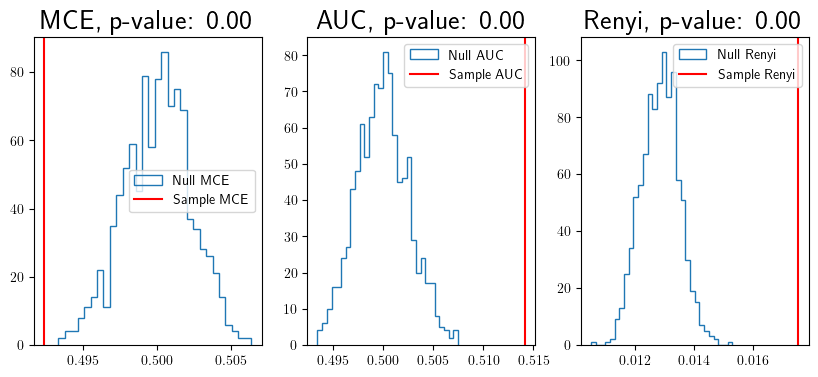

 33%|███▎      | 1/3 [00:05<00:10,  5.38s/it]

p_value_MCE: 0.0, p_value_AUC: 0.0, p_value_RENYI: 0.0


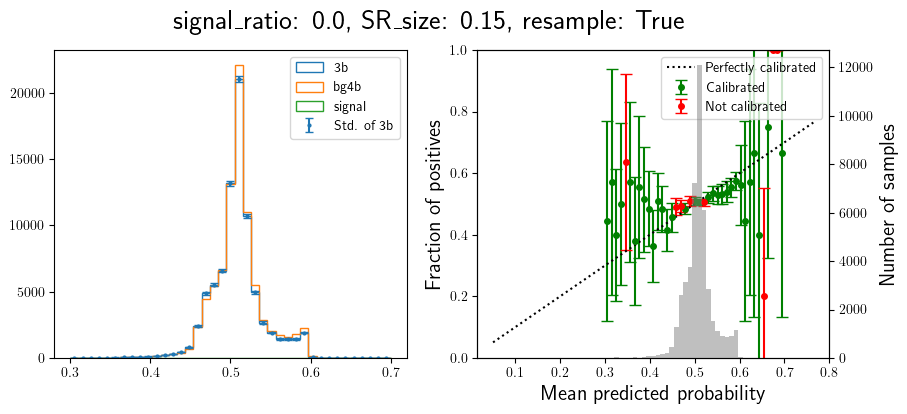

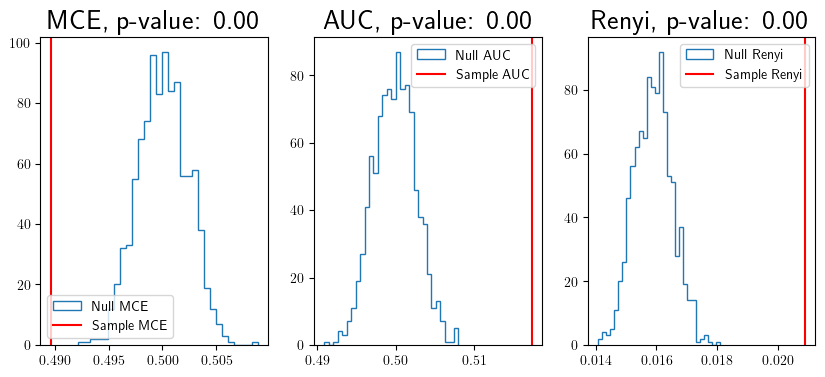

 67%|██████▋   | 2/3 [00:10<00:05,  5.51s/it]

p_value_MCE: 0.0, p_value_AUC: 0.0, p_value_RENYI: 0.0


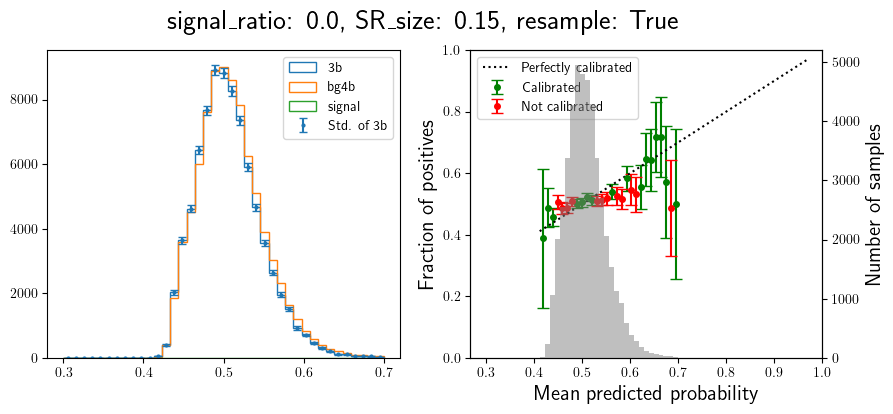

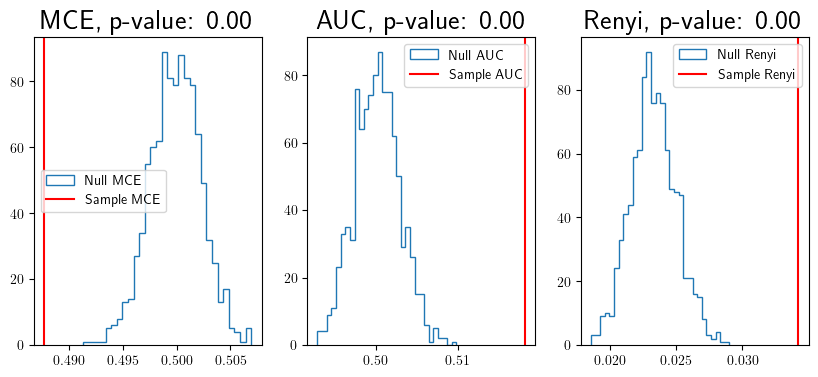

100%|██████████| 3/3 [00:16<00:00,  5.36s/it]


signal_ratio 0.0 SR_CR_size 0.2 0.8


  0%|          | 0/3 [00:00<?, ?it/s]

p_value_MCE: 0.0, p_value_AUC: 0.0, p_value_RENYI: 0.0


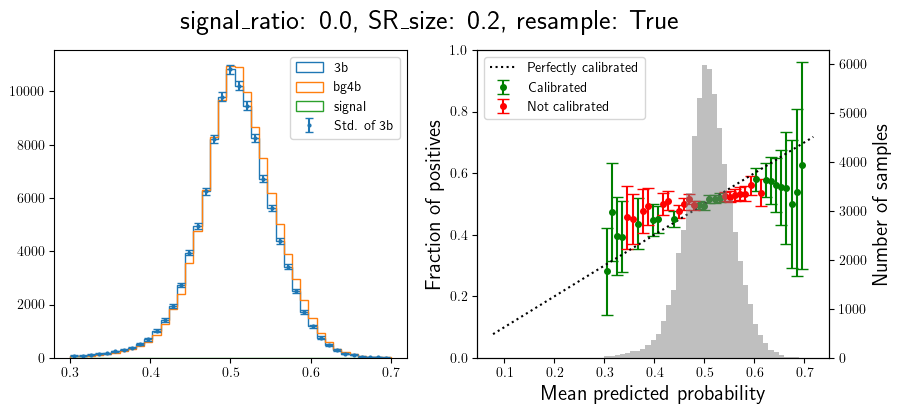

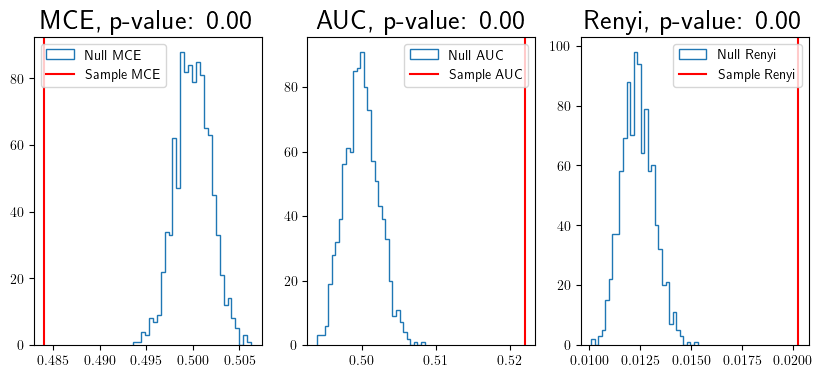

 33%|███▎      | 1/3 [00:06<00:13,  6.57s/it]

p_value_MCE: 0.0, p_value_AUC: 0.0, p_value_RENYI: 0.0


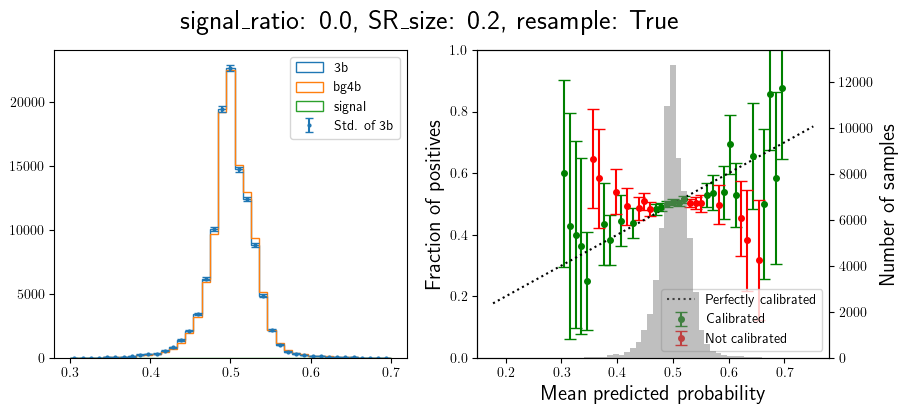

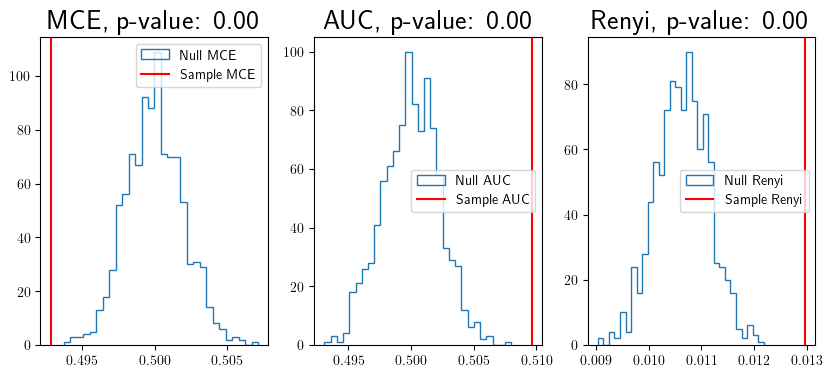

 67%|██████▋   | 2/3 [00:13<00:06,  6.49s/it]

p_value_MCE: 0.0, p_value_AUC: 0.0, p_value_RENYI: 0.0


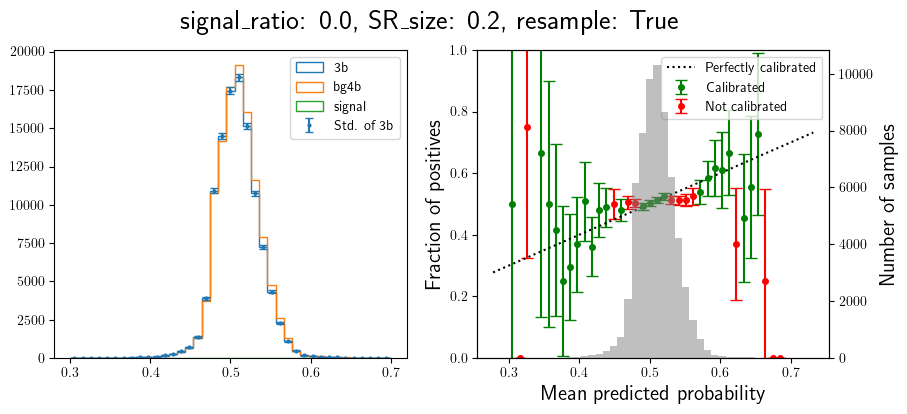

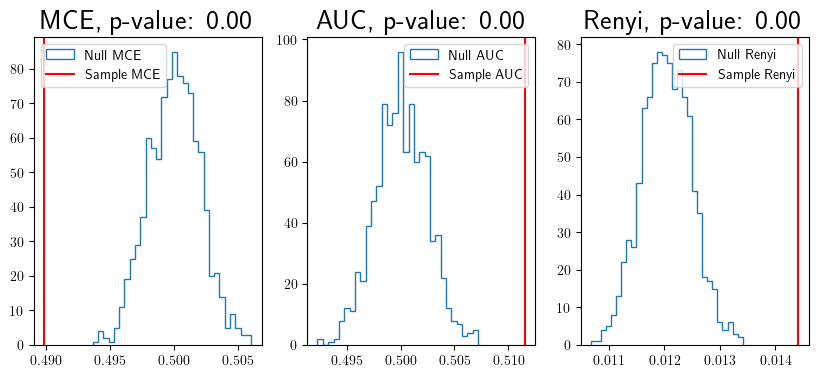

100%|██████████| 3/3 [00:19<00:00,  6.56s/it]


In [7]:
from plots import calibration_plot
from signal_region import get_SR_CR_cut, compute_sr_stats
from events_data import get_is_signal
from utils import select_random_true_elements
from mi_test import mi_test

n_3b = 100_0000
ratio_4b = 0.5
signal_filename = "HH4b_picoAOD.h5"
experiment_name = "CR_fvt_training_ensemble_max_smeared"
N_REPS = 1000
tst_seed = 42

SR_CR_sizes = [
    (0.05, 0.95), 
    (0.1, 0.9),
    (0.15, 0.85),
    (0.2, 0.8),
               ]

np.random.seed(42)

calib_bins = np.linspace(0.3, 0.7, 40)  
signal_ratios = [0.0]
p_values_dict = {sr[0]: {} for sr in SR_CR_sizes}
sig_level = 0.05

for signal_ratio in signal_ratios:
    for SR_size, CR_size in SR_CR_sizes:
        print("signal_ratio", signal_ratio, "SR_CR_size", SR_size, CR_size)
        hparams_filter = {
            "experiment_name": experiment_name,
            "aux_info_step": 3,
            "dataset": lambda x: (
                x["n_3b"] == n_3b
                and x["ratio_4b"] == ratio_4b
                and x["signal_filename"] == signal_filename
                and x["signal_ratio"] == signal_ratio
                and x["seed"] <= 2
            ),
            "signal_region": lambda x: (
                x["4b_in_SR"] == SR_size and x["4b_in_CR"] == CR_size
            ),
        }
        CR_fvt_hashes = TrainingInfo.find(hparams_filter)
        
        
        p_value_MCE_list = []
        p_value_AUC_list = []
        p_value_RENYI_list = []
        
        for CR_fvt_hash in tqdm.tqdm(CR_fvt_hashes):
            hparams_filter = {"CR_fvt_hash": CR_fvt_hash, "dataloader": lambda x: x["batch_size"] == 256, "resample": True}
            mi_test_hash = TrainingInfo.find(hparams_filter)
            if not len(mi_test_hash) == 1:
                for h in mi_test_hash:
                    print(TrainingInfo.load(h).hparams)
                raise ValueError("len(mi_test_hash) != 1")
            mi_test_hash = mi_test_hash[0]
            mi_test_tinfo = TrainingInfo.load(mi_test_hash)
            CR_fvt_tinfo = TrainingInfo.load(CR_fvt_hash)
            SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
            ensemble_mode = CR_fvt_tinfo.hparams["signal_region"]["ensemble_mode"]
            stats_type = CR_fvt_tinfo.hparams["signal_region"]["stats_type"]
            signal_filename = CR_fvt_tinfo.hparams["dataset"]["signal_filename"]

            ms_idx = TrainingInfo.load(SR_stats_hashes[0]).ms_idx
            msamples = MotherSamples.load(CR_fvt_tinfo.ms_hash)
            train_scdinfo = msamples.scdinfo[ms_idx]
            tst_scdinfo = msamples.scdinfo[~ms_idx]

            df_train = train_scdinfo.fetch_data(loaded_df)
            df_train["signal"] = get_is_signal(train_scdinfo, signal_filename)
            events_train = EventsData.from_dataframe(df_train, features)

            df_tst = tst_scdinfo.fetch_data(loaded_df)
            df_tst["signal"] = get_is_signal(tst_scdinfo, signal_filename)
            events_tst = EventsData.from_dataframe(df_tst, features)

            SR_stats_train, SR_stats_tst = compute_sr_stats(
                SR_stats_hashes,
                signal_filename,
                ensemble_mode,
                stats_type,
                loaded_df,
            )
            
            SR_cut, _ = get_SR_CR_cut(
                SR_stats_train, events_train, CR_fvt_tinfo.hparams["signal_region"]
            )
            SR_idx = SR_stats_tst >= SR_cut
            
            mi_test_test_ratio = mi_test_tinfo.hparams["mi_test_dataset"]["test_ratio"]
            mi_test_data_seed = mi_test_tinfo.hparams["mi_test_dataset"]["data_seed"]
            
            events_tst_SR = events_tst[SR_idx]
            fvt_scores_tst_SR = mi_test_tinfo.aux_info["fvt_scores_tst_SR"]
            reweights_tst_SR = mi_test_tinfo.aux_info["reweights_tst_SR"]
            events_tst_SR_reweighted = events_tst_SR.clone()
            events_tst_SR_reweighted.reweight(reweights_tst_SR * events_tst_SR.weights)
            
            test_sampling_seed = mi_test_data_seed + 1
            np.random.seed(test_sampling_seed)
            p_sample = events_tst_SR_reweighted.weights / events_tst_SR_reweighted.weights.sum()
            test_idx = np.random.choice(len(events_tst_SR), 
                                        size=int(mi_test_test_ratio * len(events_tst_SR)), 
                                        replace=True, 
                                        p=p_sample)
            events_tst_SR_test = events_tst_SR_reweighted[test_idx]
            events_tst_SR_test.reweight(np.ones_like(events_tst_SR_test.weights))
            pi = mi_test_tinfo.aux_info["pi"]
            fvt_scores_tst_SR_test = fvt_scores_tst_SR[test_idx]
            
            auc_score_orig, mce_score_orig, renyi_score_orig, auc_score_null, mce_score_null, renyi_score_null = mi_test(
                fvt_scores_tst_SR_test,
                events_tst_SR_test.is_4b,
                events_tst_SR_test.weights,
                pi,
                "permutation",
                N_REPS,
                tst_seed,
                do_tqdm=False,
            )
            
            p_value_MCE = np.sum(mce_score_null <= mce_score_orig) / N_REPS
            p_value_AUC = np.sum(auc_score_null >= auc_score_orig) / N_REPS
            p_value_RENYI = np.sum(renyi_score_null >= renyi_score_orig) / N_REPS
            p_value_MCE_list.append(p_value_MCE)
            p_value_AUC_list.append(p_value_AUC)
            p_value_RENYI_list.append(p_value_RENYI)
            
            print(f"p_value_MCE: {p_value_MCE}, p_value_AUC: {p_value_AUC}, p_value_RENYI: {p_value_RENYI}")
            
            fig, ax = plt.subplots(1, 2, figsize=(10, 4))
            fig.suptitle(f"signal_ratio: {signal_ratio}, SR_size: {SR_size}, resample: {mi_test_tinfo.hparams['resample']}")
            hist_events_by_labels(events_tst_SR_reweighted, fvt_scores_tst_SR, bins=calib_bins, ax=ax[0], 
                                  errorbar=True)
            calibration_plot(
                fvt_scores_tst_SR_test,
                events_tst_SR_test.is_4b,
                bins=calib_bins,
                sample_weights=events_tst_SR_test.weights,
                ax=ax[1]
            )
            ax[0].legend()
            ax[1].legend()
            plt.show()
            
            fig, ax = plt.subplots(1, 3, figsize=(10, 4))
            ax[0].hist(mce_score_null, bins=30, label="Null MCE", histtype="step")
            ax[0].axvline(mce_score_orig, color="red", label="Sample MCE")
            ax[0].legend()
            ax[0].set_title(f"MCE, p-value: {p_value_MCE:.2f}")
            
            ax[1].hist(auc_score_null, bins=30, label="Null AUC", histtype="step")
            ax[1].axvline(auc_score_orig, color="red", label="Sample AUC")
            ax[1].legend()
            ax[1].set_title(f"AUC, p-value: {p_value_AUC:.2f}")
            
            ax[2].hist(renyi_score_null, bins=30, label="Null Renyi", histtype="step")
            ax[2].axvline(renyi_score_orig, color="red", label="Sample Renyi")
            ax[2].legend()
            ax[2].set_title(f"Renyi, p-value: {p_value_RENYI:.2f}")
            plt.show()

        
        p_value_MCE_list = np.array(p_value_MCE_list)
        p_value_AUC_list = np.array(p_value_AUC_list)
        p_value_RENYI_list = np.array(p_value_RENYI_list)
        # print(f"SR_size: {SR_size}, signal_ratio: {signal_ratio}")
        # print("MCE", np.mean(p_value_MCE_list < sig_level))
        # print(p_value_MCE_list)
        # print("AUC", np.mean(p_value_AUC_list < sig_level))
        # print(p_value_AUC_list)
        # print("Renyi", np.mean(p_value_RENYI_list < sig_level))
        # print(p_value_RENYI_list)
        p_values_dict[SR_size][signal_ratio] = {
            "MCE": p_value_MCE_list,
            "AUC": p_value_AUC_list,
            "Renyi": p_value_RENYI_list
        }
        
        

In [5]:
from plots import calibration_plot
from signal_region import get_SR_CR_cut, compute_sr_stats
from events_data import get_is_signal
from utils import select_random_true_elements
from mi_test import mi_test

n_3b = 100_0000
ratio_4b = 0.5
signal_filename = "HH4b_picoAOD.h5"
experiment_name = "CR_fvt_training_ensemble_max_smeared"
N_REPS = 1000
tst_seed = 42

SR_CR_sizes = [
    (0.05, 0.95), 
    (0.1, 0.9),
    (0.15, 0.85),
    (0.2, 0.8),
               ]

np.random.seed(42)

calib_bins = np.linspace(0.3, 0.7, 40)  
# signal_ratios = [0.0]
signal_ratios = [0.0, 0.005, 0.0075, 0.01, 0.02]
p_values_dict = {sr[0]: {} for sr in SR_CR_sizes}
sig_level = 0.05

for signal_ratio in signal_ratios:
    for SR_size, CR_size in SR_CR_sizes:
        print("signal_ratio", signal_ratio, "SR_CR_size", SR_size, CR_size)
        hparams_filter = {
            "experiment_name": experiment_name,
            "aux_info_step": 3,
            "dataset": lambda x: (
                x["n_3b"] == n_3b
                and x["ratio_4b"] == ratio_4b
                and x["signal_filename"] == signal_filename
                and x["signal_ratio"] == signal_ratio
                # and x["seed"] <= 2
            ),
            "signal_region": lambda x: (
                x["4b_in_SR"] == SR_size and x["4b_in_CR"] == CR_size
            ),
        }
        CR_fvt_hashes = TrainingInfo.find(hparams_filter)
        
        p_value_MCE_list = []
        p_value_AUC_list = []
        p_value_RENYI_list = []
        
        for CR_fvt_hash in tqdm.tqdm(CR_fvt_hashes):
            hparams_filter = {"CR_fvt_hash": CR_fvt_hash, "dataloader": lambda x: x["batch_size"] == 256, 
                              "resample": lambda x: not x}
            mi_test_hash = TrainingInfo.find(hparams_filter)
            if not len(mi_test_hash) == 1:
                for h in mi_test_hash:
                    print(TrainingInfo.load(h).hparams)
                raise ValueError("len(mi_test_hash) != 1")
            mi_test_hash = mi_test_hash[0]
            mi_test_tinfo = TrainingInfo.load(mi_test_hash)
            CR_fvt_tinfo = TrainingInfo.load(CR_fvt_hash)
            SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
            ensemble_mode = CR_fvt_tinfo.hparams["signal_region"]["ensemble_mode"]
            stats_type = CR_fvt_tinfo.hparams["signal_region"]["stats_type"]
            signal_filename = CR_fvt_tinfo.hparams["dataset"]["signal_filename"]

            ms_idx = TrainingInfo.load(SR_stats_hashes[0]).ms_idx
            msamples = MotherSamples.load(CR_fvt_tinfo.ms_hash)
            train_scdinfo = msamples.scdinfo[ms_idx]
            tst_scdinfo = msamples.scdinfo[~ms_idx]

            df_train = train_scdinfo.fetch_data(loaded_df)
            df_train["signal"] = get_is_signal(train_scdinfo, signal_filename)
            events_train = EventsData.from_dataframe(df_train, features)

            df_tst = tst_scdinfo.fetch_data(loaded_df)
            df_tst["signal"] = get_is_signal(tst_scdinfo, signal_filename)
            events_tst = EventsData.from_dataframe(df_tst, features)

            SR_stats_train, SR_stats_tst = compute_sr_stats(
                SR_stats_hashes,
                signal_filename,
                ensemble_mode,
                stats_type,
                loaded_df,
            )
            
            SR_cut, _ = get_SR_CR_cut(
                SR_stats_train, events_train, CR_fvt_tinfo.hparams["signal_region"]
            )
            SR_idx = SR_stats_tst >= SR_cut
            
            SR_3b_idx = events_tst.is_3b & SR_idx
            SR_4b_idx = events_tst.is_4b & SR_idx
            
            mi_test_test_ratio = mi_test_tinfo.hparams["mi_test_dataset"]["test_ratio"]
            mi_test_data_seed = mi_test_tinfo.hparams["mi_test_dataset"]["data_seed"]

            # select test_ratio of the events in the SR for 3b and 4b
            SR_3b_test_idx = select_random_true_elements(
                SR_3b_idx,
                mi_test_test_ratio,
                mi_test_data_seed,
            )
            SR_4b_test_idx = select_random_true_elements(
                SR_4b_idx,
                mi_test_test_ratio,
                mi_test_data_seed,
            )
            
            SR_test_idx = SR_3b_test_idx | SR_4b_test_idx
            events_tst_SR_test = events_tst[SR_test_idx]
            events_tst_SR_train = events_tst[SR_idx & ~SR_test_idx]
            fvt_scores_tst_SR_test = mi_test_tinfo.aux_info["fvt_scores_tst_SR_test"]
            reweights_tst_SR_test = mi_test_tinfo.aux_info["reweights_tst_SR_test"]
            reweights_tst_SR_train = mi_test_tinfo.aux_info["reweights_tst_SR_train"]
            
            SR_test_idx = SR_3b_test_idx | SR_4b_test_idx
            SR_test_idx_in_SR_tst = SR_test_idx[SR_idx]
            
            tst_idx = np.zeros_like(SR_3b_test_idx, dtype=int)
            tst_idx[SR_3b_test_idx] = 1
            tst_idx[SR_4b_test_idx] = 2
            tst_idx = tst_idx[tst_idx != 0]
            SR_3b_test_idx = tst_idx == 1
            SR_4b_test_idx = tst_idx == 2
            
            CR_fvt_scores_tst_SR_test = (CR_fvt_tinfo.aux_info["fvt_scores_tst_SR"])[SR_test_idx_in_SR_tst]
            CR_reweights_tst_SR_test = np.where(
                events_tst_SR_test.is_4b,
                1,
                CR_fvt_scores_tst_SR_test / (1 - CR_fvt_scores_tst_SR_test))
            events_tst_SR_test_clone = events_tst_SR_test.clone()
            events_tst_SR_test_clone.reweight(CR_reweights_tst_SR_test * events_tst_SR_test.weights)
            
            weights_test = events_tst_SR_test.weights * reweights_tst_SR_test
            weights_train = events_tst_SR_train.weights * reweights_tst_SR_train
            
            SR_3b_train_idx = events_tst_SR_train.is_3b
            SR_4b_train_idx = events_tst_SR_train.is_4b
            w_3b_train = np.sum(weights_train[SR_3b_train_idx])
            n_3b_train = np.sum(SR_3b_train_idx)
            w_4b_train = np.sum(weights_train[SR_4b_train_idx])
            n_4b_train = np.sum(SR_4b_train_idx)
            
            pi = w_4b_train / (w_3b_train + w_4b_train)
            
            # resample from events_tst_SR_test
            test_sampling_seed = mi_test_data_seed + 1
            fvt_scores_tst_SR_test_final = []
            events_tst_SR_test_final = []
            
            for idx in [events_tst_SR_test_clone.is_3b, events_tst_SR_test_clone.is_4b]:
                events_tst_SR_test_clone_b = events_tst_SR_test_clone[idx]
                
                p_sample_b = events_tst_SR_test_clone_b.weights / events_tst_SR_test_clone_b.weights.sum()
                np.random.seed(test_sampling_seed)
                test_idx_b = np.random.choice(len(events_tst_SR_test_clone_b), 
                                        size=int(np.sum(events_tst_SR_test_clone_b.weights)), 
                                        replace=True, 
                                        p=p_sample_b)
                fvt_scores_tst_SR_test_final.append(fvt_scores_tst_SR_test[idx][test_idx_b])
                events_tst_SR_test_final.append(events_tst_SR_test_clone_b[test_idx_b])
                
            events_tst_SR_test_final = EventsData.merge(events_tst_SR_test_final)
            events_tst_SR_test_final.reweight(np.ones_like(events_tst_SR_test_final.weights))
            fvt_scores_tst_SR_test_final = np.concatenate(fvt_scores_tst_SR_test_final)
            
            auc_score_orig, mce_score_orig, renyi_score_orig, auc_score_null, mce_score_null, renyi_score_null = mi_test(
                fvt_scores_tst_SR_test_final,
                events_tst_SR_test_final.is_4b,
                events_tst_SR_test_final.weights,
                pi,
                "permutation",
                N_REPS,
                tst_seed,
                do_tqdm=False,
            )
            
            p_value_MCE = np.sum(mce_score_null <= mce_score_orig) / N_REPS
            p_value_AUC = np.sum(auc_score_null >= auc_score_orig) / N_REPS
            p_value_RENYI = np.sum(renyi_score_null >= renyi_score_orig) / N_REPS
            p_value_MCE_list.append(p_value_MCE)
            p_value_AUC_list.append(p_value_AUC)
            p_value_RENYI_list.append(p_value_RENYI)
            
            # fig, ax = plt.subplots(1, 2, figsize=(10, 4))
            # fig.suptitle(f"signal_ratio: {signal_ratio}, SR_size: {SR_size}, resample: {mi_test_tinfo.hparams.get('resample', False)}")
            # hist_events_by_labels(events_tst_SR_test_final, fvt_scores_tst_SR_test_final, bins=calib_bins, ax=ax[0], 
            #                       errorbar=True)
            # calibration_plot(
            #     fvt_scores_tst_SR_test_final,
            #     events_tst_SR_test_final.is_4b,
            #     bins=calib_bins,
            #     sample_weights=events_tst_SR_test_final.weights,
            #     ax=ax[1]
            # )
            # ax[0].legend()
            # ax[1].legend()
            # plt.show()
            
            # print(f"p_value_MCE: {p_value_MCE}, p_value_AUC: {p_value_AUC}, p_value_RENYI: {p_value_RENYI}")
        
        p_value_MCE_list = np.array(p_value_MCE_list)
        p_value_AUC_list = np.array(p_value_AUC_list)
        p_value_RENYI_list = np.array(p_value_RENYI_list)
        # print(f"SR_size: {SR_size}, signal_ratio: {signal_ratio}")
        # print("MCE", np.mean(p_value_MCE_list < sig_level))
        # print(p_value_MCE_list)
        # print("AUC", np.mean(p_value_AUC_list < sig_level))
        # print(p_value_AUC_list)
        # print("Renyi", np.mean(p_value_RENYI_list < sig_level))
        # print(p_value_RENYI_list)
        p_values_dict[SR_size][signal_ratio] = {
            "MCE": p_value_MCE_list,
            "AUC": p_value_AUC_list,
            "Renyi": p_value_RENYI_list
        }

signal_ratio 0.0 SR_CR_size 0.05 0.95


100%|██████████| 50/50 [02:27<00:00,  2.95s/it]


signal_ratio 0.0 SR_CR_size 0.1 0.9


100%|██████████| 50/50 [03:12<00:00,  3.85s/it]


signal_ratio 0.0 SR_CR_size 0.15 0.85


...

100%|██████████| 50/50 [03:08<00:00,  3.77s/it]


signal_ratio 0.02 SR_CR_size 0.15 0.85


100%|██████████| 50/50 [04:05<00:00,  4.91s/it]


signal_ratio 0.02 SR_CR_size 0.2 0.8


100%|██████████| 50/50 [05:06<00:00,  6.12s/it]


In [6]:
# with open("p_values_dict_mi_test_resample.pkl", "wb") as f:
#     pickle.dump(p_values_dict, f)

In [8]:
sig_level = 0.05
for SR_size in p_values_dict:
    for signal_ratio in p_values_dict[SR_size]:
        print("SR_size", SR_size, "signal_ratio", signal_ratio)
        print("MCE rej rate", np.mean(p_values_dict[SR_size][signal_ratio]["MCE"] < sig_level))
        print("AUC rej rate", np.mean(p_values_dict[SR_size][signal_ratio]["AUC"] < sig_level))
        print("Renyi rej rate", np.mean(p_values_dict[SR_size][signal_ratio]["Renyi"] < sig_level))
        


SR_size 0.05 signal_ratio 0.0
MCE rej rate 0.4
AUC rej rate 0.4
Renyi rej rate 0.5
SR_size 0.05 signal_ratio 0.005
MCE rej rate 0.38
AUC rej rate 0.32
Renyi rej rate 0.36
SR_size 0.05 signal_ratio 0.0075
MCE rej rate 0.52
AUC rej rate 0.56
Renyi rej rate 0.64
SR_size 0.05 signal_ratio 0.01
MCE rej rate 0.96
AUC rej rate 0.98
Renyi rej rate 1.0
SR_size 0.05 signal_ratio 0.02
MCE rej rate 1.0
AUC rej rate 1.0
Renyi rej rate 1.0
SR_size 0.1 signal_ratio 0.0
MCE rej rate 0.4
AUC rej rate 0.42
Renyi rej rate 0.48
SR_size 0.1 signal_ratio 0.005
MCE rej rate 0.38
AUC rej rate 0.36
Renyi rej rate 0.42
SR_size 0.1 signal_ratio 0.0075
MCE rej rate 0.5
AUC rej rate 0.58
Renyi rej rate 0.58
SR_size 0.1 signal_ratio 0.01
MCE rej rate 0.96
AUC rej rate 0.98
Renyi rej rate 0.98
SR_size 0.1 signal_ratio 0.02
MCE rej rate 1.0
AUC rej rate 1.0
Renyi rej rate 1.0
SR_size 0.15 signal_ratio 0.0
MCE rej rate 0.26
AUC rej rate 0.34
Renyi rej rate 0.36
SR_size 0.15 signal_ratio 0.005
MCE rej rate 0.44
AUC rej